In [1]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd
from sklearn.utils import shuffle
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import GridSearchCV

## Preparing the data

In [2]:
def numeric_columns(df):
    numeric_cols = []
    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            numeric_cols.append(col)
    return numeric_cols
# Load dataset
df = pd.read_csv("12 features - no imp.csv")

# Use function to extract numeric columns
numeric_cols = numeric_columns(df)
# print(df_num.shape)
# print(df_num.columns)
# print(df_num['MHW_count'].value_counts())

# Create a copy of the DataFrame
df_numeric = df[numeric_cols].copy()

# Now you can safely modify df_numeric
#df_numeric['mhw_count'] = df_numeric['mhw_count'].astype(str)

df_numeric.loc[df_numeric['mhw_count'].isin([2, 3]), 'mhw_count'] = 2


print(df_numeric['mhw_count'].value_counts())

# Shuffle the DataFrame
shuffled_df_numeric = shuffle(df_numeric, random_state=42)

# Separate features (X) and labels (y) after shuffling
X = shuffled_df_numeric.drop(['mhw_count'], axis=1)
y = shuffled_df_numeric['mhw_count']
X.shape, y.shape

mhw_count
0    3245
1     663
2     158
Name: count, dtype: int64


((4066, 11), (4066,))

## First classifier

cross validation scores: [0.96805897 0.97662977 0.97785978 0.95571956 0.97416974]
0.9705 accuracy with a standard deviation of 0.0081
Accuracy: 97.54%
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       650
           1       0.95      0.92      0.93       133
           2       0.93      0.90      0.92        31

    accuracy                           0.98       814
   macro avg       0.96      0.94      0.95       814
weighted avg       0.98      0.98      0.98       814

[[644   5   1]
 [ 10 122   1]
 [  2   1  28]]


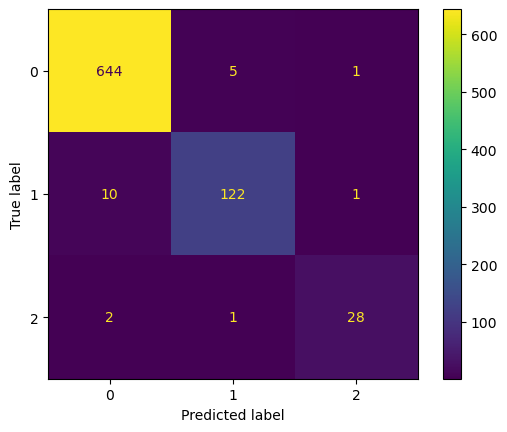

In [10]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify = y, test_size=0.2, random_state=42)
# Initialize the XGBClassifier
model = xgb.XGBClassifier(verbosity = 1, random_state = 42)
# Train the model
model.fit(X_train, y_train)
# Make predictions
y_pred = model.predict(X_test)
# Evaluate the model
cross_val_scores = cross_val_score(model, X, y, cv=5)
print('cross validation scores:', cross_val_scores)
print("%0.4f accuracy with a standard deviation of %0.4f" % (cross_val_scores.mean(), cross_val_scores.std()))
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
print(cm)
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)

In [4]:
# explicitly require this experimental feature
#from sklearn.experimental import enable_halving_search_cv # noqa
# now you can import normally from model_selection
#from sklearn.model_selection import HalvingGridSearchCV


param_grid = [
    {'learning_rate': [0.1, 0.3, 0.5],
     'gamma': [0, 0.5, 1],
     'max_depth': [3, 6, 10],
     'min_child_weight': [1, 3, 5 ],
     'subsample': [0.5, 1],
     'reg_lambda': [1, 2],
     'reg_alpha': [0, 1]
}]
grid = GridSearchCV(model, param_grid, cv = 5, scoring = 'accuracy', verbose = 1)
model_grid = grid.fit(X_train, y_train)
print('the best score was', str(model_grid.best_score_))
print('the best parameters were', str(model_grid.best_params_))
pd.DataFrame(model_grid.cv_results_)

Fitting 5 folds for each of 648 candidates, totalling 3240 fits
the best score was 0.9744766631218245
the best parameters were {'gamma': 0, 'learning_rate': 0.1, 'max_depth': 10, 'min_child_weight': 1, 'reg_alpha': 0, 'reg_lambda': 1, 'subsample': 0.5}


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_gamma,param_learning_rate,param_max_depth,param_min_child_weight,param_reg_alpha,param_reg_lambda,param_subsample,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.239806,0.004197,0.007662,0.000823,0.0,0.1,3,1,0,1,0.5,"{'gamma': 0, 'learning_rate': 0.1, 'max_depth'...",0.964670,0.963134,0.970769,0.966154,0.952308,0.963407,0.006109,467
1,0.232265,0.002746,0.007523,0.000759,0.0,0.1,3,1,0,1,1.0,"{'gamma': 0, 'learning_rate': 0.1, 'max_depth'...",0.955453,0.955453,0.961538,0.967692,0.947692,0.957566,0.006704,567
2,0.282787,0.017783,0.009384,0.001183,0.0,0.1,3,1,0,2,0.5,"{'gamma': 0, 'learning_rate': 0.1, 'max_depth'...",0.953917,0.956989,0.970769,0.966154,0.952308,0.960027,0.007198,529
3,0.289270,0.004442,0.009977,0.000142,0.0,0.1,3,1,0,2,1.0,"{'gamma': 0, 'learning_rate': 0.1, 'max_depth'...",0.947773,0.963134,0.963077,0.967692,0.946154,0.957566,0.008832,567
4,0.261021,0.012882,0.008130,0.000718,0.0,0.1,3,1,1,1,0.5,"{'gamma': 0, 'learning_rate': 0.1, 'max_depth'...",0.947773,0.956989,0.967692,0.963077,0.947692,0.956645,0.008030,576
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
643,0.188763,0.003912,0.007879,0.001278,1.0,0.5,10,5,0,2,1.0,"{'gamma': 1, 'learning_rate': 0.5, 'max_depth'...",0.966206,0.966206,0.973846,0.964615,0.960000,0.966175,0.004459,411
644,0.216416,0.003943,0.008814,0.001027,1.0,0.5,10,5,1,1,0.5,"{'gamma': 1, 'learning_rate': 0.5, 'max_depth'...",0.950845,0.958525,0.970769,0.969231,0.950769,0.960028,0.008630,527
645,0.242194,0.064269,0.008724,0.000511,1.0,0.5,10,5,1,1,1.0,"{'gamma': 1, 'learning_rate': 0.5, 'max_depth'...",0.947773,0.964670,0.972308,0.966154,0.956923,0.961565,0.008460,494
646,0.244809,0.013985,0.009074,0.000672,1.0,0.5,10,5,1,2,0.5,"{'gamma': 1, 'learning_rate': 0.5, 'max_depth'...",0.955453,0.950845,0.972308,0.963077,0.952308,0.958798,0.007967,550


In [5]:
param_grid = [
    {'learning_rate': [0.05, 0.1, 0.2],
     'max_depth': [8, 10, 12],
     'subsample': [0.4, 0.5, 0.6, 0.7]
}]
grid = GridSearchCV(model, param_grid, cv = 5, scoring = 'accuracy', verbose = 1)
model_grid = grid.fit(X_train, y_train)
print('the best score was', str(model_grid.best_score_))
print('the best parameters were', str(model_grid.best_params_))
pd.DataFrame(model_grid.cv_results_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
the best score was 0.9744780810587264
the best parameters were {'learning_rate': 0.1, 'max_depth': 8, 'subsample': 0.4}


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_learning_rate,param_max_depth,param_subsample,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.623320,0.033284,0.008775,0.001972,0.05,8,0.4,"{'learning_rate': 0.05, 'max_depth': 8, 'subsa...",0.963134,0.969278,0.976923,0.978462,0.972308,0.972021,0.005515,32
1,0.749791,0.037528,0.009379,0.000952,0.05,8,0.5,"{'learning_rate': 0.05, 'max_depth': 8, 'subsa...",0.960061,0.970814,0.973846,0.978462,0.972308,0.971098,0.006085,34
2,0.723803,0.053121,0.009331,0.000738,0.05,8,0.6,"{'learning_rate': 0.05, 'max_depth': 8, 'subsa...",0.970814,0.969278,0.975385,0.978462,0.970769,0.972942,0.003438,20
3,0.748315,0.045750,0.009381,0.000685,0.05,8,0.7,"{'learning_rate': 0.05, 'max_depth': 8, 'subsa...",0.969278,0.972350,0.973846,0.980000,0.969231,0.972941,0.003954,21
4,0.815084,0.044897,0.009722,0.000355,0.05,10,0.4,"{'learning_rate': 0.05, 'max_depth': 10, 'subs...",0.963134,0.970814,0.975385,0.978462,0.973846,0.972328,0.005217,30
5,0.883506,0.012592,0.010877,0.000595,0.05,10,0.5,"{'learning_rate': 0.05, 'max_depth': 10, 'subs...",0.963134,0.970814,0.973846,0.978462,0.969231,0.971097,0.005075,35
6,0.932311,0.025130,0.009587,0.000782,0.05,10,0.6,"{'learning_rate': 0.05, 'max_depth': 10, 'subs...",0.967742,0.970814,0.975385,0.978462,0.970769,0.972634,0.003801,28
7,0.933499,0.015820,0.010239,0.000784,0.05,10,0.7,"{'learning_rate': 0.05, 'max_depth': 10, 'subs...",0.970814,0.973886,0.973846,0.980000,0.969231,0.973555,0.003686,10
8,0.881213,0.011373,0.010648,0.000955,0.05,12,0.4,"{'learning_rate': 0.05, 'max_depth': 12, 'subs...",0.964670,0.967742,0.976923,0.978462,0.970769,0.971713,0.005272,33
9,0.998265,0.096497,0.010287,0.000762,0.05,12,0.5,"{'learning_rate': 0.05, 'max_depth': 12, 'subs...",0.966206,0.969278,0.973846,0.976923,0.967692,0.970789,0.003996,36


In [6]:
param_grid = [
    {'learning_rate': [0.1],
     'max_depth': [7, 8, 9],
     'subsample': [0.2, 0.3, 0.4]
}]
grid = GridSearchCV(model, param_grid, cv = 5, scoring = 'accuracy', verbose = 1)
model_grid = grid.fit(X_train, y_train)
print('the best score was', str(model_grid.best_score_))
print('the best parameters were', str(model_grid.best_params_))
pd.DataFrame(model_grid.cv_results_)

Fitting 5 folds for each of 9 candidates, totalling 45 fits
the best score was 0.9744780810587264
the best parameters were {'learning_rate': 0.1, 'max_depth': 8, 'subsample': 0.4}


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_learning_rate,param_max_depth,param_subsample,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.457080,0.011036,0.008518,0.000690,0.1,7,0.2,"{'learning_rate': 0.1, 'max_depth': 7, 'subsam...",0.967742,0.966206,0.976923,0.978462,0.963077,0.970482,0.006096,9
1,0.562960,0.044593,0.009137,0.001113,0.1,7,0.3,"{'learning_rate': 0.1, 'max_depth': 7, 'subsam...",0.967742,0.967742,0.976923,0.978462,0.964615,0.971097,0.005526,8
2,0.598764,0.031339,0.010044,0.001273,0.1,7,0.4,"{'learning_rate': 0.1, 'max_depth': 7, 'subsam...",0.970814,0.972350,0.978462,0.978462,0.970769,0.974171,0.003549,2
3,0.526253,0.035817,0.009943,0.001272,0.1,8,0.2,"{'learning_rate': 0.1, 'max_depth': 8, 'subsam...",0.967742,0.969278,0.980000,0.978462,0.966154,0.972327,0.005743,4
4,0.623322,0.027297,0.010277,0.000659,0.1,8,0.3,"{'learning_rate': 0.1, 'max_depth': 8, 'subsam...",0.969278,0.969278,0.978462,0.978462,0.964615,0.972019,0.005529,6
5,0.620655,0.042030,0.008839,0.000983,0.1,8,0.4,"{'learning_rate': 0.1, 'max_depth': 8, 'subsam...",0.973886,0.972350,0.978462,0.978462,0.969231,0.974478,0.003582,1
6,0.609907,0.007737,0.010376,0.000867,0.1,9,0.2,"{'learning_rate': 0.1, 'max_depth': 9, 'subsam...",0.967742,0.969278,0.978462,0.980000,0.966154,0.972327,0.005743,4
7,0.662254,0.005104,0.010091,0.000920,0.1,9,0.3,"{'learning_rate': 0.1, 'max_depth': 9, 'subsam...",0.969278,0.969278,0.976923,0.978462,0.964615,0.971711,0.005195,7
8,0.706794,0.007655,0.011448,0.000719,0.1,9,0.4,"{'learning_rate': 0.1, 'max_depth': 9, 'subsam...",0.972350,0.975422,0.975385,0.980000,0.967692,0.974170,0.004057,3


## Best classifier

[00:25:06] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:53: Finished constructing the `IterativeDMatrix`: (3252, 11, 33606).
[00:25:07] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:53: Finished constructing the `IterativeDMatrix`: (3252, 11, 33708).
[00:25:07] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:53: Finished constructing the `IterativeDMatrix`: (3253, 11, 33592).
[00:25:08] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:53: Finished constructing the `IterativeDMatrix`: (3253, 11, 33698).
[00:25:09] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:53: Finished constructing the `IterativeDMatrix`: (3253, 11, 33711).
[00:25:09] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:53: Finished constructing the `IterativeDMatrix`: (3253, 11, 33679).
cross validation scores: [0.97174447 0.97539975 0.97539975 0.959

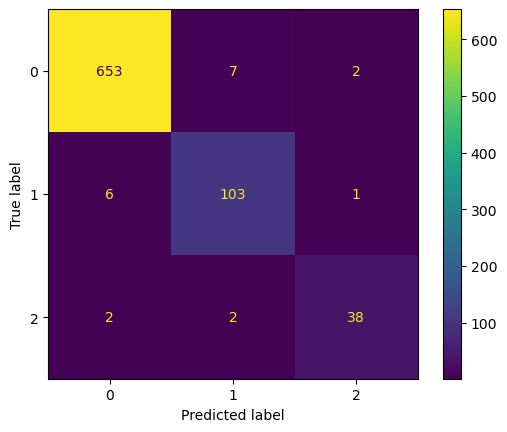

In [9]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify = y, test_size=0.2, random_state=42)
# Initialize the XGBClassifier
model = xgb.XGBClassifier(eta = 0.1, max_depth = 8, subsample = 0.4, verbosity = 2, random_state = 42)
# Train the model
model.fit(X_train, y_train)
# Make predictions
y_pred = model.predict(X_test)
# Evaluate the model
cross_val_scores = cross_val_score(model, X, y, cv=5)
print('cross validation scores:', cross_val_scores)
print("%0.4f accuracy with a standard deviation of %0.4f" % (cross_val_scores.mean(), cross_val_scores.std()))
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
print(cm)
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)

In [4]:
feature_names = X.columns
feature_importance = pd.DataFrame(model.feature_importances_, index = feature_names).sort_values(0, ascending=False)
feature_importance

,0
iron,0.095268
nitrite,0.067018
sea surface quantum fluorescence,0.058258
ammonium,0.054087
nitrate and nitrite.4,0.043514
...,...
silva_ace,0.000000
sea ice free start,0.000000
sea ice conc,0.000000
silva_species_rich,0.000000


<Axes: >

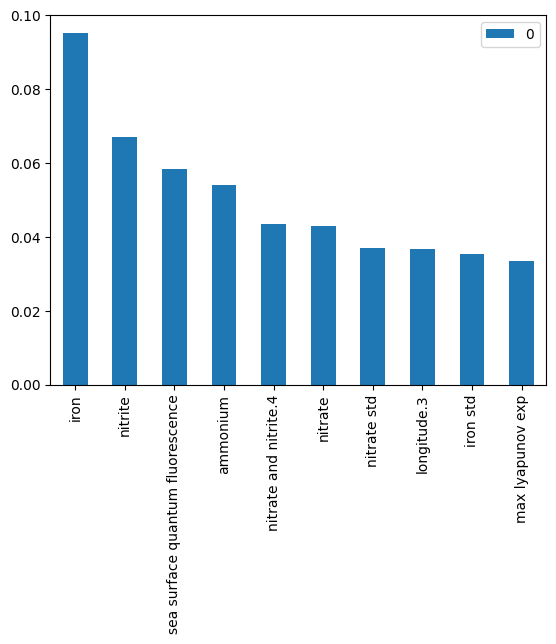

In [5]:
feature_importance.head(10).plot(kind='bar')

<Axes: >

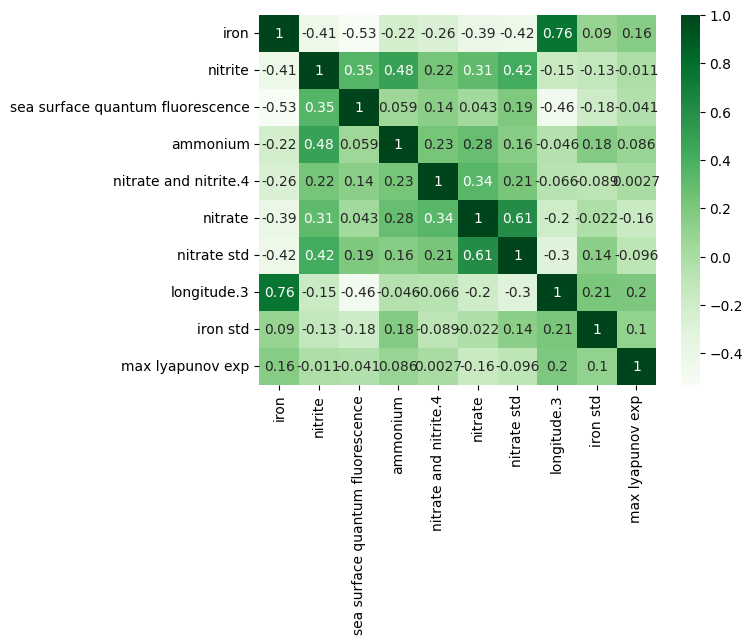

In [6]:
# 1. Get top N features
top_n = 10
top_features = feature_importance.head(top_n).index.tolist()

# 2. Filter dataset for top features
X_top = X[top_features]

# 3. Compute correlation matrix
correlation_matrix = X_top.corr()

#X = feature_importance.iloc[0:20]
#matrix = X.corr()

# plotting correlation matrix
sns.heatmap(correlation_matrix, cmap="Greens", annot=True)

## Permutation importance

In [7]:
def get_perm_importance(model, X, y, features, n=5):

    """
    Calculate permutation importance score for each feature
    """

    # Calculate baseline score (without permuting any feature)
    baseline_score = model.score(X, y)

    importance_scores = {}

    # Loop over each feature
    for feature in features:

        X_perm = X.copy()
        sum_score = 0

        # Repeat n times to get average importance score
        for i in range(n):
           
            # Calculate score when given feature is permuted
            X_perm[feature]= np.random.permutation(X_perm[feature])
            permuted_score = model.score(X_perm, y)

            sum_score += permuted_score

        # Calculate decrease in score
        importance_score = baseline_score - sum_score/n
        importance_scores[feature] = importance_score

    return importance_scores

Text(0.5, 0, 'Permutation Importance')

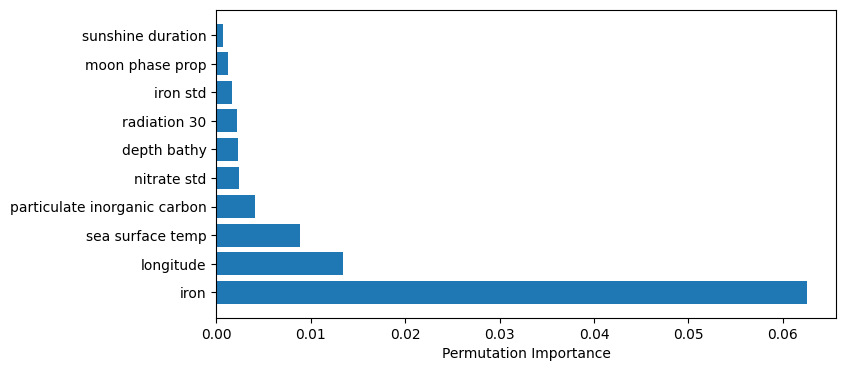

In [8]:
# Calculate permutation feature importance
importance_scores = get_perm_importance(model, X, y, X.columns,n=10)

# Display the importance scores using a horizontal bar plot
sorted_importance_scores = sorted(importance_scores.items(), key=lambda x: x[1], reverse = True)[:10]
features, scores = zip(*sorted_importance_scores)

plt.subplots(figsize=(8,4))
plt.barh(features, scores)
plt.xlabel('Permutation Importance')

# Save figure
#utils.save_fig("MA0_fearture_importance")

## LIME

In [18]:
from lime.lime_tabular import LimeTabularExplainer
# Create the explainer
explainer = LimeTabularExplainer(X.values, 
                                   feature_names=X.columns, 
                                   class_names=['rings'], 
                                   mode='classification',
                                 kernel_width = 5,
                                 discretize_continuous = False,
                                 verbose = True,                                
                                   random_state=42)

In [19]:
constant_features = X.columns[X.std() == 0]
X = X.drop(columns=constant_features)
# Get explanation for first row
exp = explainer.explain_instance(X.iloc[0], 
                                 model.predict, 
                                labels=X.columns
                                )

#Display explanation
exp.show_in_notebook(show_table=True)

exp.save_to_file('explanation_1.html')

ValueError: Input contains NaN.

In [21]:
import shap
# Visualize the SHAP values for the first prediction
shap.initjs()  # Initialize JS visualization

# Get shap values
explainer = shap.Explainer(model)
shap_values = explainer(X)
print(np.shape(shap_values))

(4525, 80, 3)


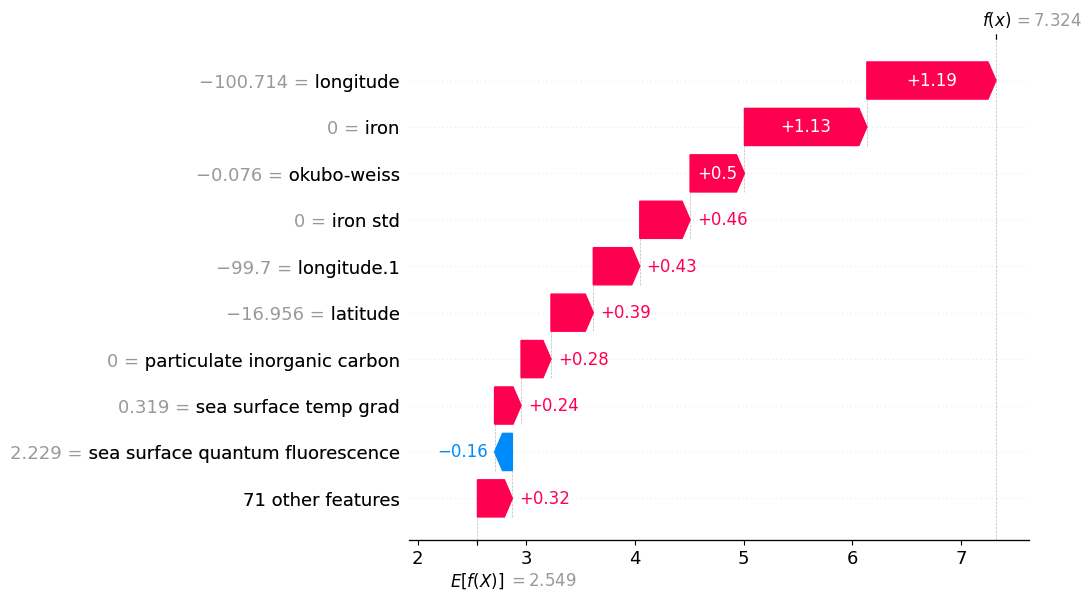

In [24]:
# Waterfall plot for first observation
shap.plots.waterfall(shap_values[0, :, 0])

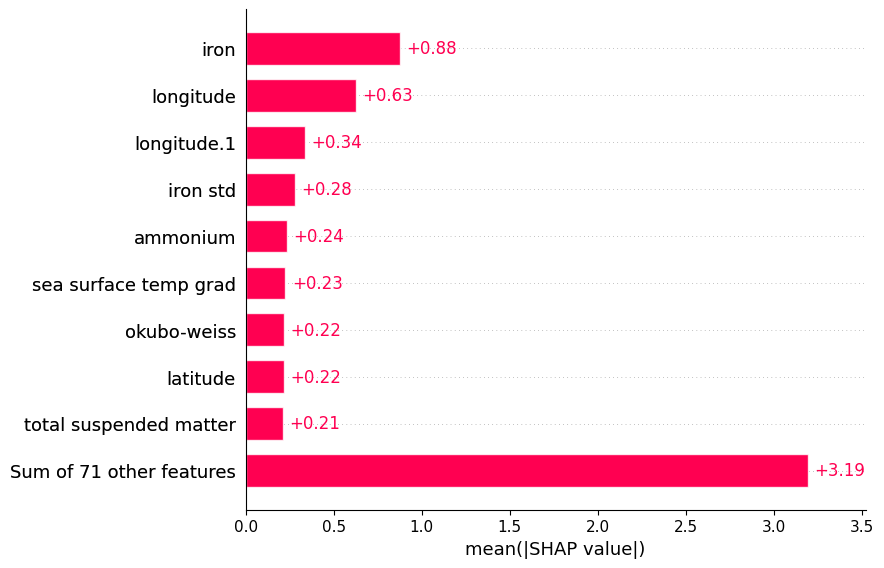

In [31]:
# Plot for a specific class (most commonly class 1)
shap.plots.bar(shap_values[..., 0])  # Replace 1 with your target class

cross validation scores: [0.98121547 0.9878453  0.98563536 0.98674033 0.99116022]
0.9865 accuracy with a standard deviation of 0.0032
Accuracy: 98.90%
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       734
           1       0.98      0.95      0.97       149
           2       1.00      1.00      1.00        22

    accuracy                           0.99       905
   macro avg       0.99      0.98      0.99       905
weighted avg       0.99      0.99      0.99       905

[[731   3   0]
 [  7 142   0]
 [  0   0  22]]


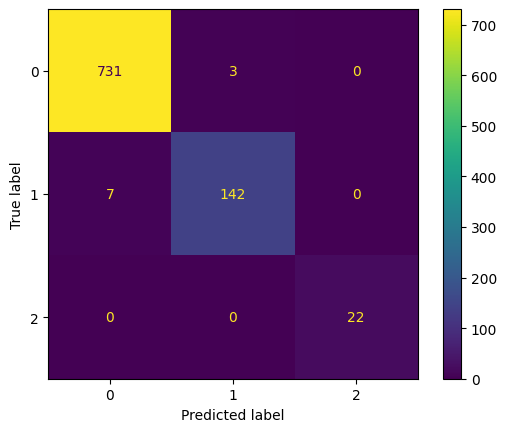

In [9]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Initialize the XGBClassifier
model = xgb.XGBClassifier(gamma = 0, learning_rate = 0.5, max_depth = 10, reg_alpha = 0,
                          reg_lambda = 2, subsample = 0.7, verbosity = 2, random_state = 42)
# Train the model
model.fit(X_train, y_train)
# Make predictions
y_pred = model.predict(X_test)
# Evaluate the model
cross_val_scores = cross_val_score(model, X, y, cv=5)
print('cross validation scores:', cross_val_scores)
print("%0.4f accuracy with a standard deviation of %0.4f" % (cross_val_scores.mean(), cross_val_scores.std()))
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
print(cm)
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)

cross validation scores: [0.97900552 0.98895028 0.99005525 0.98674033 0.99116022]
0.9872 accuracy with a standard deviation of 0.0043
Accuracy: 99.01%
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       734
           1       0.99      0.95      0.97       149
           2       1.00      1.00      1.00        22

    accuracy                           0.99       905
   macro avg       0.99      0.98      0.99       905
weighted avg       0.99      0.99      0.99       905

[[732   2   0]
 [  7 142   0]
 [  0   0  22]]


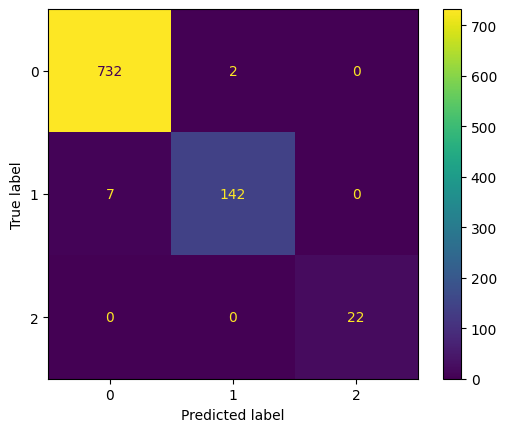

In [5]:
# Split the data into training and testing sets
X_train_1000, X_test_1000, y_train_1000, y_test_1000 = train_test_split(X, y, test_size=0.2, random_state=42)
# Initialize the XGBClassifier
model_1000 = xgb.XGBClassifier(n_estimators = 1000, verbosity = 2, random_state = 42)
# Train the model
model_1000.fit(X_train_1000, y_train_1000)
# Make predictions
y_pred_1000 = model_1000.predict(X_test_1000)
# Evaluate the model
cross_val_scores_1000 = cross_val_score(model_1000, X, y, cv=5)
print('cross validation scores:', cross_val_scores_1000)
print("%0.4f accuracy with a standard deviation of %0.4f" % (cross_val_scores_1000.mean(), cross_val_scores_1000.std()))
accuracy_1000 = accuracy_score(y_test_1000, y_pred_1000)
print(f"Accuracy: {accuracy_1000 * 100:.2f}%")
print(classification_report(y_test_1000, y_pred_1000))
cm_1000 = confusion_matrix(y_test_1000, y_pred_1000)
print(cm_1000)
ConfusionMatrixDisplay.from_estimator(model_1000, X_test_1000, y_test_1000)

In [8]:
feature_names = X.columns
feature_importance_1000 = pd.DataFrame(model_1000.feature_importances_, index = feature_names).sort_values(0, ascending=False)
feature_importance_1000

,0
nitrite,0.112852
iron,0.112303
sea surface quantum fluorescence,0.071773
longitude.3,0.053133
latitude.2,0.045003
...,...
silva_chao,0.000000
sea ice free start,0.000000
sea ice conc,0.000000
silva_species_rich,0.000000


<Axes: >

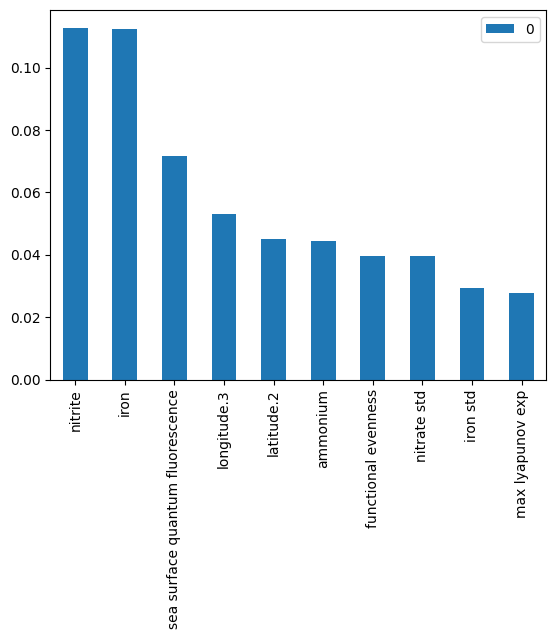

In [9]:
feature_importance_1000.head(10).plot(kind='bar')